In [1]:
import os
import fnmatch
import pandas as pd
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
left =  135
upper = 13
right = 740
lower = 618
crop_box = (left, upper, right, lower)

In [3]:
df = pd.read_csv('image_data_1.csv')
img = Image.open('Filtered_T_Image.tif').crop(crop_box)

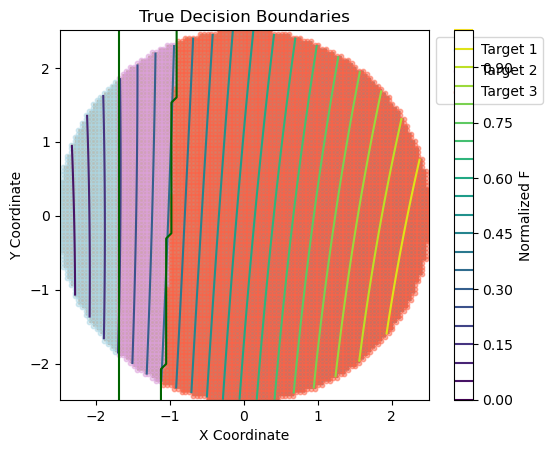

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from PIL import Image

# Load data
df = pd.read_csv('image_data_1.csv')
img = Image.open('Filtered_T_Image.tif').crop(crop_box)

# Function to plot the contour of normalized 'F' and targets on the same figure
def plot_contour_and_targets(df, img):
    # Normalize F to [0, 1]
    df['F_normalized'] = (df['F'] - df['F'].min()) / (df['F'].max() - df['F'].min())

    # Interpolate NaNs using pandas' interpolate method
    df['F_normalized'] = df['F_normalized'].interpolate(method='linear')

    # Create grid for contouring
    xi = np.linspace(df['x'].min(), df['x'].max(), 100)
    yi = np.linspace(df['y'].min(), df['y'].max(), 100)
    Xi, Yi = np.meshgrid(xi, yi)

    # Interpolate F onto the grid
    F_grid = griddata((df['x'], df['y']), df['F_normalized'], (Xi, Yi), method='linear')

    # Create a figure and axis
    fig, ax = plt.subplots()

    # Plot the contour directly
    contour = ax.contour(Xi, Yi, F_grid, levels=20)
    plt.colorbar(contour, label="Normalized F")

    # Display the image
    ax.imshow(img, extent=[df['x'].min(), df['x'].max(), df['y'].min(), df['y'].max()], alpha=0.5)

    # Plot points based on target values
    colors = {1: 'lightblue', 2: 'plum', 3: 'tomato'}

    # Plot each unique coordinate for each target
    for target in colors.keys():
        target_points = df[df['target'] == target]

        # Use the coordinates to plot the points on the image
        ax.scatter(target_points['x'], target_points['y'],
                   color=colors[target],
                   label=f'Target {target}',
                   s=10,
                   alpha=0.5)

    # Set the axis limits to match the coordinate range
    ax.set_xlim([df['x'].min(), df['x'].max()])
    ax.set_ylim([df['y'].min(), df['y'].max()])

    # Encode the target labels
    le = LabelEncoder()
    df['target_encoded'] = le.fit_transform(df['target'])

    # Fit logistic regression model
    X = df[['x', 'y']]
    y = df['target_encoded']
    model = LogisticRegression(multi_class='multinomial')
    model.fit(X, y)

    # Create a mesh to plot the decision boundaries
    x_min, x_max = df['x'].min() - 1, df['x'].max() + 1
    y_min, y_max = df['y'].min() - 1, df['y'].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    # Ensure xx and yy are DataFrames with the appropriate column names
    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['x', 'y'])
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Plot decision boundaries
    ax.contour(xx, yy, Z, levels=[0.5, 1.5], colors=['darkgreen', 'darkgreen'], linestyles=['-', '-'])

    # Add labels and legend
    ax.set_title('True Decision Boundaries')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # Show the plot
    plt.show()

# Plot contour and targets on the same figure
plot_contour_and_targets(df, img)